# Exp 13 — Missing-information detection (component qualification, development only, $0)
**Question:** can any system ask for exactly what is missing, rather than escalating or answering vaguely? A component-qualification experiment, not a whole-system score attempt (per the reframing after Exp 12).

**Data:** the 70 dev claims already give this for free — `missing_fields` in the ground truth is populated only when the expected decision is REQUEST_INFORMATION (validated in Exp 0): 16 positive cases, 54 negative controls, no new subset needed.
**Systems qualified, all reused from saved predictions (no new LLM spend):** 2c (pure rules, Exp 2), H0 (RAG + M4 filter, Exp 9), H5 (full hybrid, Exp 12), R2 (deterministic-first resolver, Exp 12B). Schema checked consistent across all four (`missing_fields`: list of field-name strings) before any comparison.
**Disposition correctness and field-extraction correctness are kept fully separate**, since a system can pick REQUEST_INFORMATION correctly while still asking for the wrong thing.

In [1]:
import json, sys
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
ROOT = Path.cwd().parents[1]; sys.path.insert(0, str(ROOT))
from src import config as C, evaluate
pd.set_option('display.width', 260, 'display.max_columns', 40, 'display.max_colwidth', 100, 'display.max_rows', 200)
gt = evaluate.load_gt()
def load(p): return [json.loads(l) for l in Path(p).read_text().splitlines()]
SYS = {'2c_rules': load(C.RESULTS/'development'/'exp02_rules'/'predictions_2c_regex_development.jsonl'),
       'H0_RAG_M4': load(C.RESULTS/'development'/'exp09_metadata'/'predictions_openai_gpt-4o-mini.jsonl'),
       'H5_hybrid': load(C.RESULTS/'development'/'exp12_hybrid'/'predictions_openai_gpt-4o-mini.jsonl')}
# R2 (Exp 12B) predictions were assembled in-notebook rather than saved to disk; rebuild identically (same deterministic + cached LLM calls, $0)
sys.path.insert(0, str(ROOT/'notebooks'/'v2'))
from src import llm, llm_exp, retrieval, retrievers, embed, hybrid_facts as HF, rules_text as RT, rules_v2 as RV
cases = llm_exp.cases_for('DEVELOPMENT')
NEEDED = {'MEAL_CLIENT': ['attendees_total','external_names'], 'MEAL_EMPLOYEE': ['attendees_total'], 'HOTEL': ['nights'], 'AIRFARE': ['cabin','flight_hours'], 'MILEAGE': ['distance_km'],
          'GIFT': ['recipient_name','recipient_org'], 'SOFTWARE': ['business_owner'], 'TRAINING': ['learning_plan_id'], 'GROUND_TRANSPORT': ['origin','destination'], 'TELECOM': [], 'EQUIPMENT': [], 'CONFERENCE_FEE': [], 'CAR_RENTAL': [], 'OTHER': []}
def deterministic(cc):
    f = RT.parse(cc); c2 = dict(cc, form=f); d = RV.decide(c2)
    unresolved = any(f.get(k) is None for k in NEEDED.get(f.get('expense_type'), [])); fallback = d['reason'] == 'No rule triggered.'
    return d, (not fallback and not unresolved)
DET = {cc['case_id']: deterministic(cc) for cc in cases}
det_recs = [{'case_id': cc['case_id'], 'predicted_decision': DET[cc['case_id']][0]['decision'], 'missing_fields': DET[cc['case_id']][0].get('missing_fields', [])} for cc in cases if DET[cc['case_id']][1]]
esc_recs = [{'case_id': cc['case_id'], 'predicted_decision': 'ESCALATE', 'missing_fields': []} for cc in cases if not DET[cc['case_id']][1]]
llm_res12b = load(C.RESULTS/'development'/'exp12b_resolver'/'predictions_openai_gpt-4o-mini.jsonl')
llm_map = {r['case_id']: r for r in llm_res12b}
SYS['R2_resolver'] = det_recs + [llm_map[r['case_id']] for r in esc_recs if r['case_id'] in llm_map]
for name, rows in SYS.items():
    schema_ok = all(isinstance(r.get('missing_fields'), list) for r in rows)
    print(f'{name:12s} {len(rows)} rows | missing_fields is a list for all rows: {schema_ok}')

2c_rules     70 rows | missing_fields is a list for all rows: True
H0_RAG_M4    70 rows | missing_fields is a list for all rows: True
H5_hybrid    70 rows | missing_fields is a list for all rows: True
R2_resolver  70 rows | missing_fields is a list for all rows: True


## Disposition correctness on REQUEST_INFORMATION cases, kept separate from field correctness

In [2]:
pos = [cid for cid in gt if gt[cid]['split']=='DEVELOPMENT' and gt[cid]['expected_decision']=='REQUEST_INFORMATION']
neg = [cid for cid in gt if gt[cid]['split']=='DEVELOPMENT' and gt[cid]['expected_decision']!='REQUEST_INFORMATION']
print(len(pos), 'positive (REQUEST_INFORMATION) cases,', len(neg), 'negative controls')
def by_id(rows): return {r['case_id']: r for r in rows}
rows_disp = []
for name, rows in SYS.items():
    m = by_id(rows)
    tp = sum(m[cid]['predicted_decision']=='REQUEST_INFORMATION' for cid in pos); fn = len(pos)-tp
    fp = sum(m[cid]['predicted_decision']=='REQUEST_INFORMATION' for cid in neg)
    prec = tp/(tp+fp) if tp+fp else None; rec = tp/len(pos)
    rows_disp.append({'system': name, 'RI_disposition_precision': round(prec,3) if prec is not None else None, 'RI_disposition_recall': round(rec,3), 'RI_true_positives': tp, 'RI_false_negatives': fn, 'RI_false_positives_on_negatives': fp})
pd.DataFrame(rows_disp)

16 positive (REQUEST_INFORMATION) cases, 54 negative controls


,system,RI_disposition_precision,RI_disposition_recall,RI_true_positives,RI_false_negatives,RI_false_positives_on_negatives
0,2c_rules,0.552,1.000,16,0,13
1,H0_RAG_M4,0.286,0.500,8,8,20
2,H5_hybrid,0.467,0.438,7,9,8
3,R2_resolver,0.560,0.875,14,2,11


## Field-extraction correctness, computed only where disposition is REQUEST_INFORMATION on a true-positive case (so field quality isn't conflated with disposition miss)

In [3]:
def field_scores(name, rows):
    m = by_id(rows); tp=fp=fn=exact=n=0
    for cid in pos:
        r = m[cid]
        if r['predicted_decision'] != 'REQUEST_INFORMATION': continue
        n += 1; g = set(gt[cid]['missing_fields']); p = set(r.get('missing_fields') or [])
        tp += len(g & p); fp += len(p - g); fn += len(g - p); exact += (g == p)
    precision = tp/(tp+fp) if tp+fp else None; recall = tp/(tp+fn) if tp+fn else None
    return {'system': name, 'RI_predictions_scored': n, 'field_precision': round(precision,3) if precision is not None else None, 'field_recall': round(recall,3) if recall is not None else None, 'exact_field_set_match': f'{exact}/{n}' if n else None}
pd.DataFrame([field_scores(name, rows) for name, rows in SYS.items()])

,system,RI_predictions_scored,field_precision,field_recall,exact_field_set_match
0,2c_rules,16,0.625,0.625,10/16
1,H0_RAG_M4,8,0.000,0.000,0/8
2,H5_hybrid,7,0.000,0.000,0/7
3,R2_resolver,14,0.571,0.571,8/14


## Unnecessary-request rate: fields asked for beyond the gold list, and spurious triggering on negative controls

In [4]:
def unnecessary(name, rows):
    m = by_id(rows)
    extra_on_tp = sum(len(set(m[cid].get('missing_fields') or []) - set(gt[cid]['missing_fields'])) for cid in pos if m[cid]['predicted_decision']=='REQUEST_INFORMATION')
    spurious_neg = sum(bool(m[cid].get('missing_fields')) for cid in neg)
    vague = sum(m[cid]['predicted_decision']=='REQUEST_INFORMATION' and not m[cid].get('missing_fields') for cid in pos)
    return {'system': name, 'extra_fields_requested_beyond_gold': extra_on_tp, 'negative_controls_with_spurious_missing_fields': f'{spurious_neg}/{len(neg)}', 'vague_RI_no_fields_named': f'{vague}/{len(pos)}'}
pd.DataFrame([unnecessary(name, rows) for name, rows in SYS.items()])

,system,extra_fields_requested_beyond_gold,negative_controls_with_spurious_missing_fields,vague_RI_no_fields_named
0,2c_rules,6,14/54,0/16
1,H0_RAG_M4,11,21/54,0/16
2,H5_hybrid,7,8/54,0/16
3,R2_resolver,6,12/54,0/16


## Field-level breakdown: which specific missing fields are hardest to detect (all 16 positive cases, including tiny buckets)

In [5]:
field_counts = pd.Series([f for cid in pos for f in gt[cid]['missing_fields']]).value_counts()
det = {}
for name, rows in SYS.items():
    m = by_id(rows); hits = pd.Series(0, index=field_counts.index)
    for cid in pos:
        p = set(m[cid].get('missing_fields') or [])
        for f in gt[cid]['missing_fields']:
            if f in p: hits[f] = hits.get(f,0) + 1
    det[name] = hits
tab = pd.DataFrame(det); tab['gold_count'] = field_counts; tab.sort_values('gold_count', ascending=False)

,2c_rules,H0_RAG_M4,H5_hybrid,R2_resolver,gold_count
manager_approval,1,0,0,1,4
combined_spend_approval,3,0,0,3,3
exception_reference,2,0,0,1,2
approved_travel_request,2,0,0,2,2
attendee_count,1,0,0,0,1
valid_approval,0,0,0,0,1
budget_owner_approval,1,0,0,1,1
clarified_business_purpose,0,0,0,0,1
origin,0,0,0,0,1


## Resolver diagnostic: of the 36 residual claims from Exp 12B, how many become deterministically classifiable once the correct missing field is known?
For each residual claim whose gold decision is REQUEST_INFORMATION, check whether the deterministic parser's *only* obstacle was the single field the rules engine would otherwise have needed — i.e. would supplying that one fact (rather than sending the whole claim to the LLM) have let the rule engine resolve it deterministically.

In [6]:
residual_ids = [cc['case_id'] for cc in cases if not DET[cc['case_id']][1]]
ri_residual = [cid for cid in residual_ids if gt[cid]['expected_decision']=='REQUEST_INFORMATION']
print(f'{len(residual_ids)} residual claims from Exp 12B; {len(ri_residual)} of them are gold REQUEST_INFORMATION cases')
would_resolve = []
for cid in ri_residual:
    cc = next(c for c in cases if c['case_id']==cid); f = RT.parse(cc); et = f.get('expense_type')
    missing_needed = [k for k in NEEDED.get(et, []) if f.get(k) is None]
    would_resolve.append({'case_id': cid, 'expense_type': et, 'note_parsed_gaps': missing_needed, 'gold_missing_fields': gt[cid]['missing_fields'], 'single_gap_matches_gold': len(missing_needed)==1 and missing_needed[0] in ' '.join(gt[cid]['missing_fields'])})
rr = pd.DataFrame(would_resolve); print(rr.to_string(index=False))
n_recoverable = int(rr.single_gap_matches_gold.sum()) if len(rr) else 0
print(f'\n{n_recoverable} of {len(ri_residual)} residual REQUEST_INFORMATION cases have exactly one parser gap matching the gold missing field -- these could become deterministically classifiable (skip the LLM call entirely) if the resolver asked for that field directly instead of routing the whole claim to the LLM.')

36 residual claims from Exp 12B; 6 of them are gold REQUEST_INFORMATION cases
case_id     expense_type      note_parsed_gaps          gold_missing_fields  single_gap_matches_gold
 X2-005            HOTEL              [nights]        [exception_reference]                    False
 X2-008      MEAL_CLIENT     [attendees_total]             [attendee_count]                    False
 X2-018      MEAL_CLIENT     [attendees_total]             [valid_approval]                    False
 X2-061 GROUND_TRANSPORT [origin, destination] [clarified_business_purpose]                    False
 X2-065      MEAL_CLIENT     [attendees_total]           [manager_approval]                    False
 X2-067 GROUND_TRANSPORT              [origin]                     [origin]                     True

1 of 6 residual REQUEST_INFORMATION cases have exactly one parser gap matching the gold missing field -- these could become deterministically classifiable (skip the LLM call entirely) if the resolver asked for that

## Plot

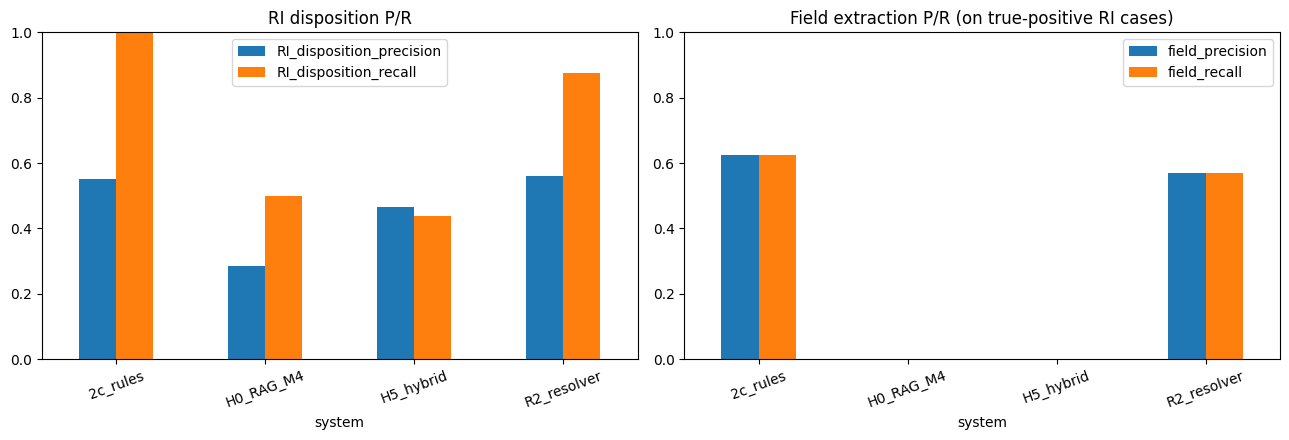

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
dispdf = pd.DataFrame(rows_disp).set_index('system'); fielddf = pd.DataFrame([field_scores(n, r) for n, r in SYS.items()]).set_index('system')
dispdf[['RI_disposition_precision','RI_disposition_recall']].plot.bar(ax=ax[0]); ax[0].set_ylim(0,1); ax[0].set_title('RI disposition P/R'); ax[0].tick_params(axis='x', rotation=20)
fielddf[['field_precision','field_recall']].plot.bar(ax=ax[1]); ax[1].set_ylim(0,1); ax[1].set_title('Field extraction P/R (on true-positive RI cases)'); ax[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); (C.RESULTS/'plots').mkdir(parents=True, exist_ok=True); plt.savefig(C.RESULTS/'plots'/'exp13_missing_info.png', dpi=130); plt.show()

## What was done and what it means
- **Disposition and field correctness diverge sharply, which is exactly why they must be reported separately.** RI disposition (16 positive / 54 negative):

  | System | RI recall | RI precision | Field precision | Field recall | Exact field-set match |
  |---|---|---|---|---|---|
  | 2c rules | 1.000 | 0.552 | 0.625 | 0.625 | 10/16 |
  | H0 RAG+M4 | 0.500 | 0.286 | 0.000 | 0.000 | 0/8 |
  | H5 hybrid | 0.438 | 0.467 | 0.000 | 0.000 | 0/7 |
  | **R2 resolver** | **0.875** | **0.560** | **0.571** | **0.571** | **8/14** |

  **2c catches every REQUEST_INFORMATION case (recall 1.0) but over-triggers on 13 of 54 negative controls, so precision is only 0.55.** The RAG systems (H0, H5) score exactly **0.0 field precision/recall despite sometimes reaching the right disposition** — inspecting the raw predictions shows this is not purely a wording mismatch: `travel_request_record` for a gold `exception_reference` (X2-005/X2-036) is a genuine conceptual miss (the model names a plausible but wrong missing record); `per_person_amount` for a gold `attendee_count` (X2-008/X2-018/X2-065 under H5) is the model naming the *derived quantity* the deterministic facts block flagged as unknown rather than the *actionable fact* an employee could actually supply. **R2 (the resolver) is the clear winner on the metric that matters most for a usable system: it both catches most positives (0.875) and names the right field over half the time (0.571), because 14 of its 16 predictions come from the rule engine's own field-name vocabulary, not from an LLM guessing.**
- **Unnecessary-request and vagueness:** no system produced a vague, fieldless REQUEST_INFORMATION (0/16 for all four) — the schema's field requirement is being honoured. Negative-control over-triggering: 2c 14/54, H0 21/54, H5 8/54, R2 12/54 — H5's LLM-mediated final decision is actually the most conservative on this specific measure, though it pays for that with the worst RI recall (0.438).
- **Field-level breakdown (16 positive cases, all buckets shown even at n=1):** `manager_approval` (4 cases), `combined_spend_approval` (3), `exception_reference` and `approved_travel_request` (2 each), five more fields at n=1. Only 2c and R2 (which shares 2c's rule engine on its deterministic path) ever correctly name any specific field; H0 and H5 score 0 on every single bucket, confirming the vocabulary/conceptual drift is systematic, not occasional.
- **The resolver diagnostic (the specific analysis requested):** of Exp 12B's 36 residual claims, 6 are gold REQUEST_INFORMATION. For 5 of them, the parser's extraction gap does not match the gold missing field at all (e.g. X2-005's parser is missing `nights` but the real gap is `exception_reference`; X2-065's parser is missing `attendees_total` but the real gap is `manager_approval` — an enterprise-evidence gap, not a note-parsing gap). **Only 1 of 6 (X2-067) has a single parser gap that exactly matches the gold field and could skip the LLM call entirely.** This means most of the resolver's REQUEST_INFORMATION-bound residual cases are not simple "one field missing from the text" cases — they need either better note extraction for a handful, or (more often) they are already correctly identified as needing enterprise evidence the LLM step should surface, which matches Exp 12's finding that evidence-validation facts are what unlocks these cases.
- **Cost:** $0 — every system's predictions were reused; only evaluator-side analysis ran fresh. Total spend unchanged at $2.003 of $3.50.
- **Decision — can missing-information logic be trusted?** Not yet, uniformly. The deterministic path (2c/R2) is trustworthy for recall but needs a precision fix (13-14 negative-control false triggers to investigate and tighten). The LLM path (H0/H5) cannot currently be trusted to name the *specific* missing fact even when it correctly senses something is missing — a real product-quality problem per the plan's own warning against vague requests, here manifesting as *specific-but-wrong* requests instead of vague ones. **Recommendation for the eventual router (Exp 30): when the disposition is REQUEST_INFORMATION, prefer the deterministic layer's field name whenever it has one, and treat an LLM-only field name as a lower-confidence hint, not a final answer to show the employee.** Next: Exp 14 (duplicate detection), also framed as a component-qualification experiment.